In [9]:
import torch
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.transforms import Compose, ToTensor, Normalize
from torch.utils.data import Dataset
from PIL import Image
import os
import torchvision.transforms as transforms
from torchvision.models.detection import faster_rcnn



In [3]:
class ImageDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.image_filenames = os.listdir(img_dir)

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        image_path = os.path.join(self.img_dir, self.image_filenames[idx])
        image = Image.open(image_path)
        if self.transform:
            image = self.transform(image)
        return image


In [4]:
# Define the dataset
trans=transforms.Compose([transforms.ToTensor(), Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])
dataset = ImageDataset(img_dir='../data/rolling/', transform=trans)

In [5]:
# Define the data loader
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)


In [10]:
# def load_model():
#     # Define the backbone network
#     backbone = resnet_fpn_backbone('resnet50', pretrained=True)

#     anchor_boxes = [64, 64, 
#                 48, 128, 
#                 64, 192, 
#                 96, 256, 
#                 128, 352, 
#                 128, 128, 
#                 192, 512, 
#                 256, 704, 
#                 352, 832, 
#                 256, 256, 
#                 512, 512, 
#                 192, 832]

#     # Define the anchor generator
#     anchor_generator = AnchorGenerator(
#         sizes=(anchor_boxes[0::2],)
#     )
   

#     roi_pooler = torchvision.ops.MultiScaleRoIAlign(featmap_names=['0'],
#                                                 output_size=7,
#                                                 sampling_ratio=2)

#     # put the pieces together inside a FasterRCNN model
#     model = FasterRCNN(backbone,
#                    num_classes=2,
#                    rpn_anchor_generator=anchor_generator,
#                    box_roi_pool=roi_pooler)
#     return model
model = torchvision.models.detection.fasterrcnn_resnet50_fpn()
num_classes = 11  # 10 digits + background
# get number of input features for the classifier
in_features = model.roi_heads.box_predictor.cls_score.in_features

# replace the pre-trained head with a new one
model.roi_heads.box_predictor = faster_rcnn.FastRCNNPredictor(in_features, num_classes)


In [11]:
# Define the device to use (CPU or GPU)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Move the model to the device
model.to(device)

# Define the optimizer and learning rate scheduler
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [8]:
# Train the model
import sys
    # caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, 'detection/')

from engine import train_one_epoch, evaluate
num_epochs = 10
for epoch in range(num_epochs):
    # Train for one epoch
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10)

    # Update the learning rate
    lr_scheduler.step()

    # Evaluate on the validation set
    evaluate(model, data_loader, device=device)

# Save the model
torch.save(model.state_dict(), 'model.pth')


ValueError: too many values to unpack (expected 2)

In [13]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

import torchvision.transforms.functional as F


ASSETS_DIRECTORY = "Rough-Digit-Classification"

plt.rcParams["savefig.bbox"] = "tight"


def show(imgs):
    if not isinstance(imgs, list):
        imgs = [imgs]
    fix, axs = plt.subplots(ncols=len(imgs), squeeze=False)
    for i, img in enumerate(imgs):
        img = img.detach()
        img = F.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

In [47]:
from torchvision.io import read_image

img_path = os.path.join(ASSETS_DIRECTORY, "JPEGImages/00450000203199_0.jpg")
mask_path = os.path.join(ASSETS_DIRECTORY, "SegmentationClass/00450000203199_0.png")
img = read_image(img_path)
mask = read_image(mask_path)

In [48]:
print(mask.size())
print(img.size())
print(mask.shape)

torch.Size([3, 480, 640])
torch.Size([3, 480, 640])
torch.Size([3, 480, 640])


In [50]:
# We get the unique colors, as these would be the object ids.
obj_ids = torch.unique(mask)

# # first id is the background, so remove it.
obj_ids = obj_ids[1:]

obj_ids

tensor([ 64, 128, 192], dtype=torch.uint8)

In [51]:
# split the color-encoded mask into a set of boolean masks.
# Note that this snippet would work as well if the masks were float values instead of ints.
masks = mask == obj_ids[:, None, None]

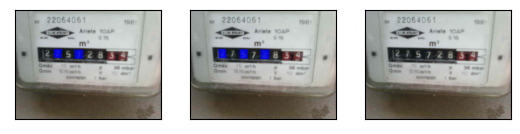

In [52]:
from torchvision.utils import draw_segmentation_masks

drawn_masks = []
for mask in masks:
    drawn_masks.append(draw_segmentation_masks(img, mask, alpha=0.8, colors="blue"))

show(drawn_masks)